## **Introducing new bias tools**

This tutorial introduces updates to `dynapse1utils` covering the new features available for setting, getting and manipulating parameters of DYNAP-SE1.

Additionally, two new tools are introduced:

- `tools.notebook_gui` - a toolkit for creating **interactive sliders** for parameters, utilizing the native Jupyter Notebook web interface. It allows creating widgets only for the parameters needed at any specific part of the notebook. Clamping of gains to leakages is introduced.

- `tools.dynapse_tuning_companion` - a **Tuning Companion** class that simplifies interaction with the chip throughout the parameter tuning process. It also comes with waveform processing and automation functions for characterizing cores in a loop, when connected to an oscilloscope.

### **1. Import Samna**

Before the start, import Samna and all other necessary packages

In [1]:
import samna
import samna.dynapse1 as dyn1

import sys
sys.path.append("..")


from dynapse1constants import *

import dynapse1utils as ut
import netgen as n
from netgen import Neuron
import time
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

Open the device

In [2]:
# open without GUI (for board connected to the remote machine)
model, _ = ut.open_dynapse1(gui=False, select_device=False)

[0]:  Bus 1 Device 3 Dynapse1DevKit serial_number 00000002
Selected device: 00000002
Sender port: tcp://0.0.0.0:40907
Receiver port: tcp://0.0.0.0:46851
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


Open visualizer if the board is connected locally:

In [3]:
ut.open_gui(model)

Visualizer start command:  /home/dzenn/anaconda3/envs/dynapse1/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75,         'tcp://0.0.0.0:46851', 'tcp://0.0.0.0:40907', 3)"


(<Thread(Thread-4, started 133438287902400)>, 'tcp://0.0.0.0:79088')

#### **1. Unifying ways to set biases. "Linear", "index" and "tuple"**

This change aims to move away from `coarse` and `fine` values that confuse many users, and instead have the only two efficient monotonously increasing maps: `linear` (proportional to the bias generator current, to be used for any relations between parameters) and `index` (goes through all valid (`coarse`, `fine`) pairs, providing the most direct control for any parameter search and automation)


In the code, parameters can now be set and retrieved using all three formats.

**`linear`** - value from 0 to 24e+08, proportional to value in pA, estimated from the bias generator model. Any relations between biases (e.g. clamping I_gain to I_tau) can be done using this format.

**`tuple`** - the coarse [0, 7] and fine [0, 255] pair. This format can still be used by those who prefer it, while it is less intuitive.

**`index`** - value from 0 to 1811 which indexes the map between **linear** and **tuple** values.

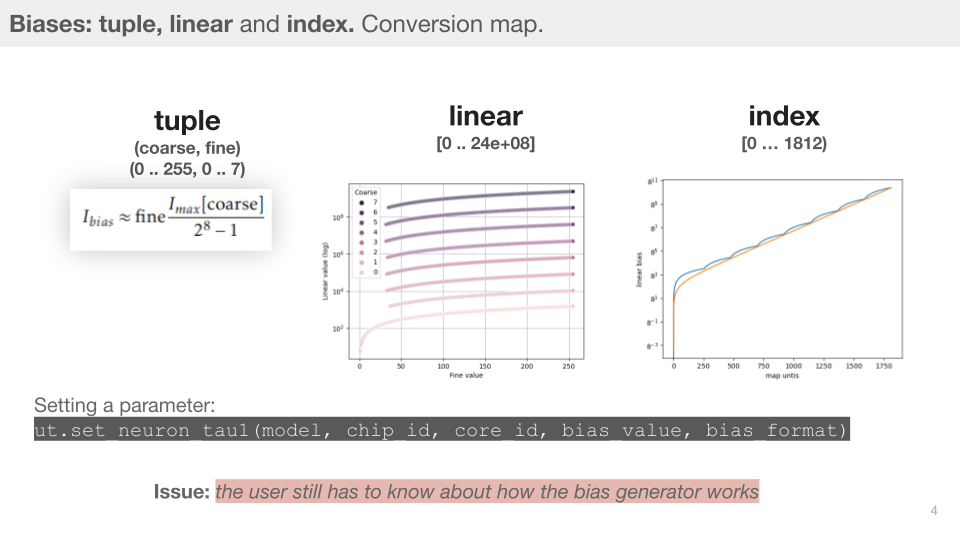


**Dynapse1utils** now contains the converter functions that convert those formats one to another.

Note that the **`linear`** bias is rounded to the nearest _valid_ value that actually corresponds to a tuple of coarse and fine.

In [ ]:
#introduce a few example bias setting to demonstrate conversion
example_tuple = (3, 100)
example_index = 105
example_linear = 578645

#test the conversion function
print("Examples of index values:",
      ut._bias_as_idx(example_tuple, "tuple"),
      ut._bias_as_idx(example_index, "index"),
      ut._bias_as_idx(example_linear, "linear"))

print("Examples of tuple values:",
      ut._bias_as_tuple(example_tuple, "tuple"),
      ut._bias_as_tuple(example_index, "index"),
      ut._bias_as_tuple(example_linear, "linear"))

print("Examples of linear value:",
      ut._bias_as_linear(example_tuple, "tuple"),
      ut._bias_as_linear(example_index, "index"),
      ut._bias_as_linear(example_linear, "linear"))

Examples of index values: 765 105 892
Examples of tuple values: (3, 100) (0, 105) (3, 227)
Examples of linear value: 254901 618 578627


Parameters can be set directly to the cores using **named functions** or through **bias tags**:

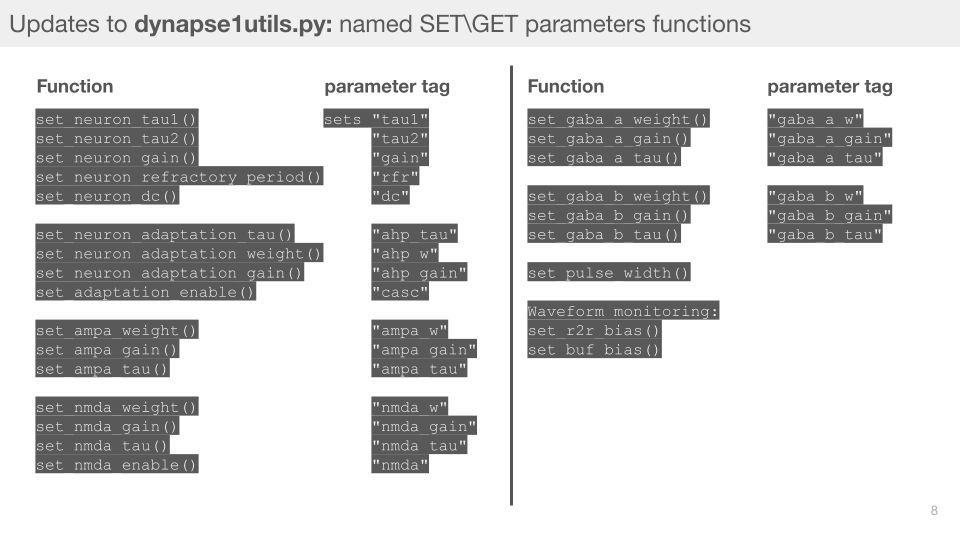

Here are a few examples

In [4]:
# set parameter as index
ut.set_neuron_dc(model, chip_id=0, core_id=0, bias_value=50, bias_format='index')


# set parameter as a tuple
ut.set_neuron_tau1(model, chip_id=0, core_id=0, bias_value=(4, 100), bias_format='tuple')

Let's get some parameters back from the `model` to see what has been set:

In [5]:
print("C1c0 refractory period bias in all formats:",
      ut.get_neuron_refractory_period(model, chip_id=1, core_id=0, bias_format="tuple"),
      ut.get_neuron_refractory_period(model, chip_id=1, core_id=0, bias_format="index"),
      ut.get_neuron_refractory_period(model, chip_id=1, core_id=0, bias_format="linear"))

C1c0 refractory period bias in all formats: (4, 3) 625 58847


Clamping $I_{gain}$ to $I_{tau}$ is now possible. Regardless of the format given, the ratio is applied to the **`linear`** value of the parameter:

In [17]:
bias_value_linear = 10000
gain_ratio = 4

ut.set_ampa_tau(model, chip_id=0, core_id=0, bias_value=bias_value_linear, bias_format='linear', fixed_gain_ratio=gain_ratio)

print("C0c0 AMPA tau as linear:",
      ut.get_ampa_tau(model, chip_id=0, core_id=0, bias_format="linear"))
print("C0c0 AMPA gain as linear:",
      ut.get_ampa_gain(model, chip_id=0, core_id=0, bias_format="linear"))

C0c0 AMPA tau as linear: 10006
C0c0 AMPA gain as linear: 39875


### **2. Setting and saving parameters of a single core**

The saved parameter set can be detached from the core and therefore can be loaded to multiple cores at once easily.
The file can also be incomplete and only contain some biases.
Short descriptions for parameter values are also included in the file by default.

In [18]:
config = model.get_configuration()

ut.save_param_group_to_txt_file(config, 1, 0, "example_core_biases.txt")


For convenience of iteratively modifying parameters in the file, the priority bias format argument is introduced. For example, one can only modify the **linear** values in the saved file, and other values would then be ignored. The function would only raise warning if the parameters are inconsistent.

Once done with tuning, simply overwrite the file with coherent values using the function above.

In [21]:
ut.set_param_group_from_txt_file(model, 0, 0, "example_core_biases.txt", priority_bias_format='linear')

PARAMETER WARNING: inconsistency between values given for parameter 'NMDA synapse time constant'; 'linear' value is applied
idx=0,	tuple=(0,0),	linear=100


**TO ADD:** A few example parameter files that work for most of the cores.

### **3. Notebook slider builder**

Now one can get sliders directly in Jupyter Notebooks and only for the parameters needed by passing a dictionary of **tags** with the `CXcx:` prefix indicating the chip and core.

Full list of tags is stored in `dynapse1constans.BIAS_TAGS`.

Once created, these sliders interactively update respective parameters.

In [ ]:
from tools.notebook_gui import make_parameter_slider_box

selected_bias_tags = ['C1c2:tau1',
                      'C1c2:ampa_w',
                      'C1c2:dc']

make_parameter_slider_box(model, selected_bias_tags, "My Network Parameters")

**Clamping gain parameters to leakages**

The slider widget allows to clamp the $I_{gain}$ of synapses and neurons to $I_{\tau}$.

While the sliders operate in `index` parameter format, the clamping of the currents is done in `linear` domain.

Note that linking of the `_tau` parameters to `_gain` parameters does not depend on the order in th `bias_tags` list.

In the builder function, there is a step that checks this list for matching `gain`/`tau` pairs (same core, same synapse type) after the layout is populated, and only afterwards links those matching pairs.

In [ ]:
bias_tags = ["C0c3:gaba_a_tau",
             "C0c3:nmda_tau",
             "C0c3:gaba_a_gain",
             "C0c2:ampa_tau",
             "C0c2:ampa_gain",
             "C0c3:nmda_gain"]

make_parameter_slider_box(model, bias_tags)

### **4. Dynapse Tuning Companion**

This is a helper class that provides input to the selected core and simplifies tuning and monitoring.

In [3]:
from tools.dynapse_tuning_companion import DynapseTuningCompanion
import netgen

net_gen = netgen.NetworkGenerator()
DTC = DynapseTuningCompanion(model, chip_id=1, core_id=2, net_gen=net_gen)

Monitor a neuron of a core:

In [ ]:
DTC.monitor_neuron(100)

Connect to the USB-connected oscilloscope (using PyGetScope submodule)

In [ ]:
DTC.connect_pyscope()

Identification string 'AGILENT TECHNOLOGIES,DSO6054A,MY44002200,06.16.0001
'
Timeout set to 15 s.
Init successful


Example of wavefore capture

array([[-0.25    ,  0.131016],
       [-0.2495  ,  0.130625],
       [-0.249   ,  0.131406],
       ...,
       [ 0.2485  ,  0.131016],
       [ 0.249   ,  0.131016],
       [ 0.2495  ,  0.131016]])

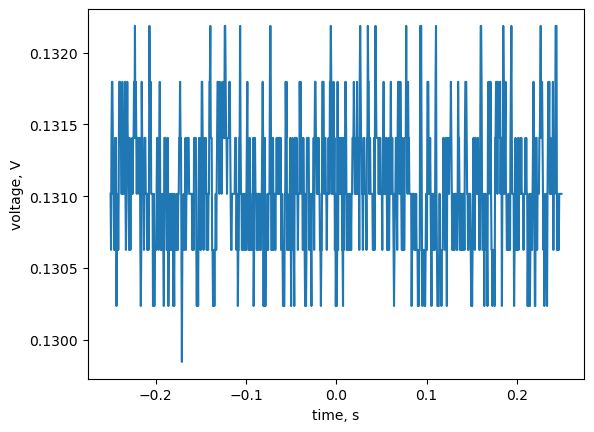

In [126]:
DTC.scope.get_waveform(1, instant_plot=True)

**Tuning Companion** simplifies sending regular spike trains to neurons.

It connects to all four synapses of every neuron of the core at the same time and sends a user defined regular rate spike train.

In [147]:
DTC.connect_spikegen()

Spikegen connected to C1c2
New configuration applied to DYNAP-SE1!



In [ ]:
DTC.set_spikegen_rate(rate_hz=20)

### **Parameter presets**

**Tuning Companion** also has parameter presets for tuning specific parameters.

Let's set board state to measure neuron time constants.

This disables synapses and DC input, lowers the neuron gain.

In [148]:
DTC.set_state_measure_neuron_tau()

**Get a single neuron TC** 

The DC input paramter is manipulated to generate square current pulses to the neuron, then the waveform is analysed, with the attempt to fit the falling part of the signal with the exponential.

**TODO:** Adjust the TC fitting script accuracy, it gives too much variance at the moment

Time constant is 20.4206 ms
Fall time is 13.5 ms
0.020420589621300268


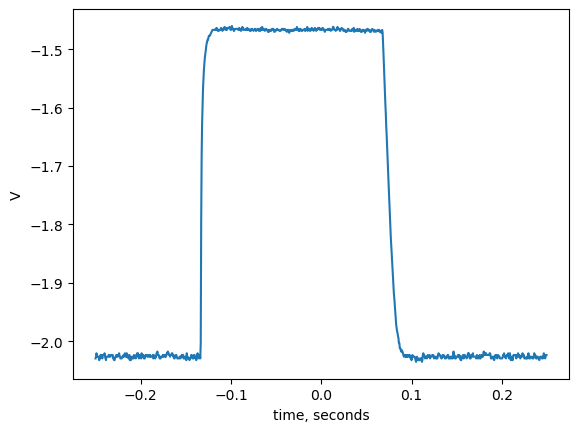

In [ ]:
wf, time_constant_s = DTC.get_neuron_time_constant(neuron_id=100,
                                                   channel_id=1,
                                                   dc_step_max_index=1100,
                                                   debug_plot=True,
                                                   debug=True)
print(time_constant_s)

**Set board state to measure neuron time constants**

This sets neuron leak to the highest possible value and provides some constant DC input and gain for measuring exitatory and inhibitory synapses

In [5]:
DTC.set_state_measure_synapses()

In [ ]:

DTC.set_spikegen_rate(rate_hz=20)

Spikegen connected to C1c2

New configuration applied to DYNAP-SE1!


In [7]:
DTC.show_synapse_parameter_controls('ampa')

No falling times!
Fitting failed, returning fall time instead
Time constant is 8 ms


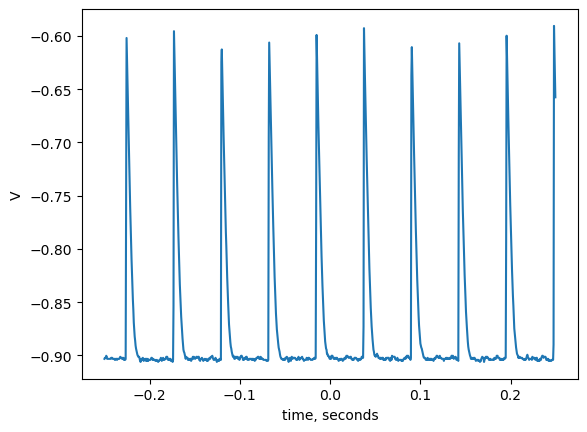

In [ ]:
wf, ampa_tc = DTC.get_synapse_time_constant(channel_id=1,
                                            syn_type='ampa',
                                            debug_plot=True,
                                            debug=True)                         # type: ignore

In [156]:
DTC.show_synapse_parameter_controls('gaba_b')

In [143]:
import importlib
import tools.dynapse_tuning_companion
import dynapse1utils
import tools
importlib.reload(tools.dynapse_tuning_companion)
importlib.reload(dynapse1utils)
importlib.reload(tools)
import dynapse1utils as ut

In [165]:
# sweep weight, tc and voltage peaks

ampa_w_all = DTC.get_all_core_values(channel_id=1, bias_tag='ampa_w')


0 0.15664000000000006
1 0.14960999999999997
2 0.15820299999999993
3 0.166796
4 0.15351600000000004
5 0.15859300000000004
6 0.15820299999999998
7 0.14257799999999998
8 0.15429700000000002
9 0.15351599999999999
10 0.15117200000000003
11 0.149219
12 0.14687500000000003
13 0.15156199999999997
14 0.144922
15 0.14492200000000005
16 0.15586
17 0.15039000000000002
18 0.16210900000000006
19 0.15351600000000004
20 0.15351500000000007
21 0.150391
22 0.15351599999999999
23 0.15898400000000001
24 0.157422
25 0.15117200000000003
26 0.141797
27 0.14765699999999993
28 0.14843700000000004
29 0.13320299999999996
30 0.15703100000000003
31 0.14062500000000006
32 0.16211000000000003
33 0.16054600000000002
34 0.15390600000000004
35 0.16054599999999997
36 0.14882800000000002
37 0.15156200000000003
38 0.15000000000000002
39 0.149219
40 0.15703099999999998
41 0.16171799999999997
42 0.15117199999999997
43 0.150781
44 0.14492200000000005
45 0.14648499999999998
46 0.14687500000000003
47 0.13554700000000003
48 0.1

Text(0, 0.5, 'Count')

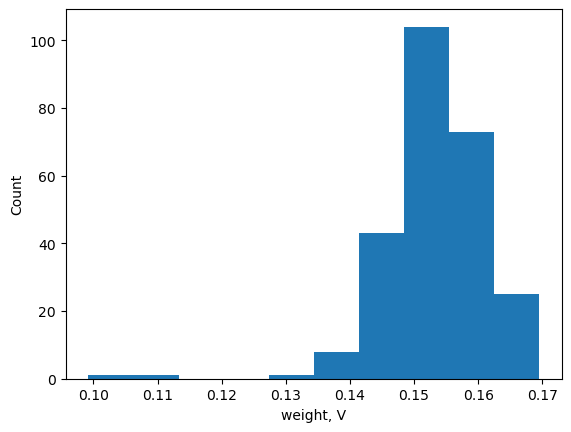

In [169]:
plt.hist(ampa_w_all)
plt.xlabel("weight, V")
plt.ylabel("Count")